In [9]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt


Considering October 31st 2025 as cutoff date: 
https://www.tagesspiegel.de/berlin/berliner-wirtschaft/arbeitskampf-bei-tiktok-beendet-content-moderatoren-erhalten-abfindungen-14780273.html



# 1. Automated Detection

In [10]:
det = pd.read_csv('data/tiktok_automation_det.csv')

In [11]:
det['application_date'] = pd.to_datetime(det['application_date'])

In [12]:
#intervention indicator
det['post'] = [1 if i > pd.to_datetime('2025-10-31') else 0 for i in det['application_date']]

### Before After Crosstab

In [13]:
ct = pd.crosstab(
    det["automated_detection"],
    det["post"],
    values=det["total"],
    aggfunc="sum",
    normalize="columns"
)

print(ct)

post                        0         1
automated_detection                    
False                0.015774  0.030542
True                 0.984226  0.969458


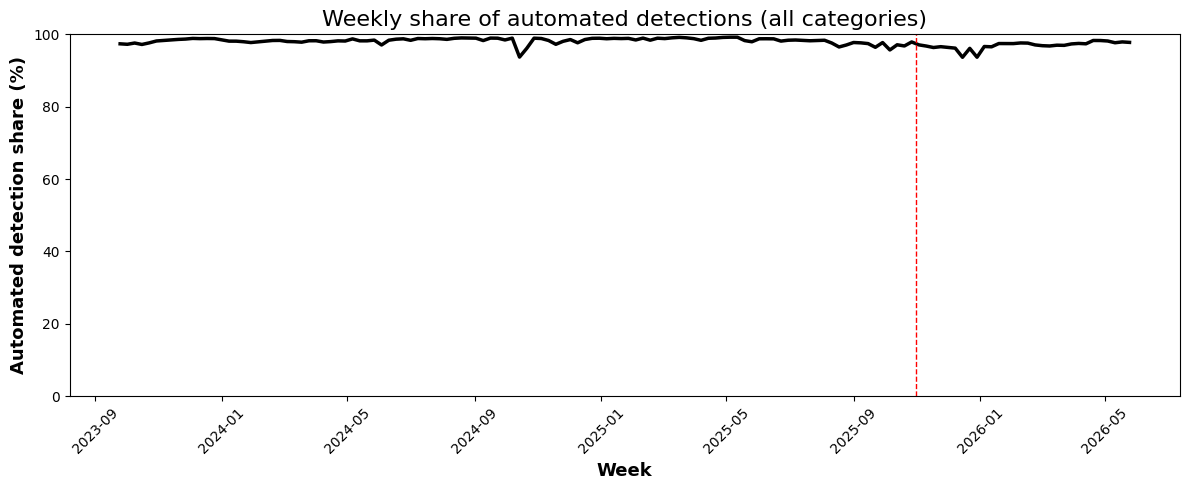

In [49]:
# Dates
det["application_date"] = pd.to_datetime(det["application_date"])

# Binary automation indicator
det["automated"] = (
    det["automated_detection"]
       .astype(str)
       .str.upper()
       .isin(["YES", "TRUE", "1"])
       .astype(int)
)

# Weekly aggregation (NO category split)
weekly_all = (
    det.assign(
        week=det["application_date"].dt.to_period("W").dt.start_time,
        automated_count=lambda x: x["total"] * x["automated"]
    )
    .groupby("week", as_index=False)
    .agg(
        total_count=("total", "sum"),
        automated_count=("automated_count", "sum")
    )
)

# Share
weekly_all["share_automated"] = (
    weekly_all["automated_count"] / weekly_all["total_count"]
)

# Policy cutoff
policy_date = pd.Timestamp("2025-10-31")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    weekly_all["week"],
    100 * weekly_all["share_automated"],
    linewidth=2.5,
    color="black"
)

ax.axvline(
    policy_date,
    linestyle="--",
    linewidth=1,
    color="red"
)

ax.set_ylim(0, 100)
ax.set_ylabel("Automated detection share (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Week", fontsize=13, fontweight="bold")
ax.set_title("Weekly share of automated detections (all categories)", fontsize=16)

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("figures/detection_all.png", dpi=300)
plt.show()

### No other TC violation

/var/folders/x5/wbn8vry53vx2_zzm426gt54h0000gn/T/ipykernel_77808/3342883307.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  det_notc["application_date"] = pd.to_datetime(det_notc["application_date"])
/var/folders/x5/wbn8vry53vx2_zzm426gt54h0000gn/T/ipykernel_77808/3342883307.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  det_notc["automated"] = (


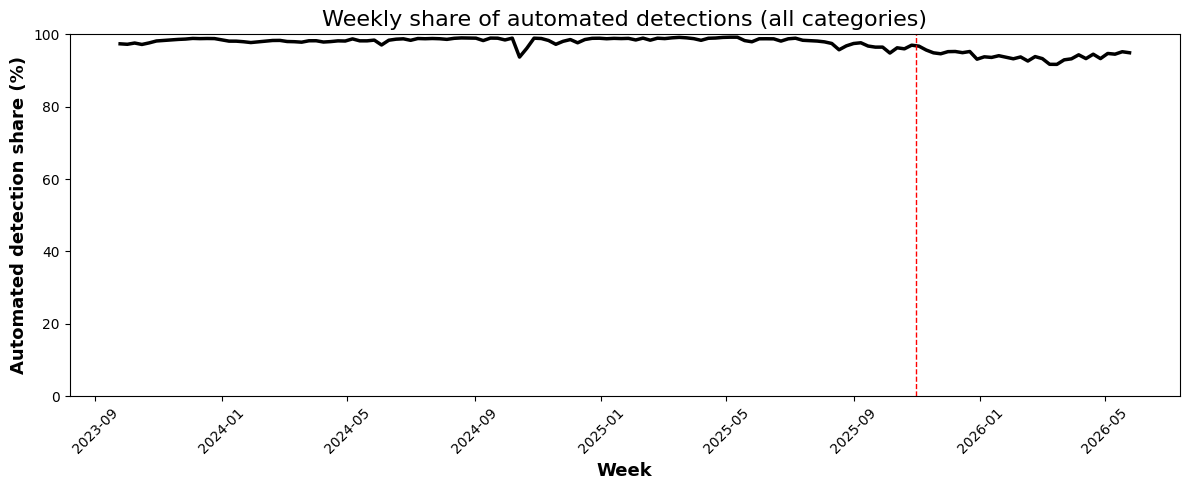

In [60]:
# Dates
det_notc = det[(det['category'] != 'STATEMENT_CATEGORY_OTHER_VIOLATION_TC')]
det_notc["application_date"] = pd.to_datetime(det_notc["application_date"])

# Binary automation indicator
det_notc["automated"] = (
    det_notc["automated_detection"]
       .astype(str)
       .str.upper()
       .isin(["YES", "TRUE", "1"])
       .astype(int)
)

# Weekly aggregation (NO category split)
weekly_all = (
    det_notc.assign(
        week=det_notc["application_date"].dt.to_period("W").dt.start_time,
        automated_count=lambda x: x["total"] * x["automated"]
    )
    .groupby("week", as_index=False)
    .agg(
        total_count=("total", "sum"),
        automated_count=("automated_count", "sum")
    )
)

# Share
weekly_all["share_automated"] = (
    weekly_all["automated_count"] / weekly_all["total_count"]
)

# Policy cutoff
policy_date = pd.Timestamp("2025-10-31")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    weekly_all["week"],
    100 * weekly_all["share_automated"],
    linewidth=2.5,
    color="black"
)

ax.axvline(
    policy_date,
    linestyle="--",
    linewidth=1,
    color="red"
)

ax.set_ylim(0, 100)
ax.set_ylabel("Automated detection share (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Week", fontsize=13, fontweight="bold")
ax.set_title("Weekly share of automated detections (all categories)", fontsize=16)

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("figures/detection_all_no_other.png", dpi=300)
plt.show()

### All detections

In [14]:
#shorten category names for display
det['category_short'] = [i[19:] for i in det['category']]

In [15]:
def compact(n):
    for unit in ["", "K", "M", "B", "T"]:
        if abs(n) < 1000:
            return f"{n:.2f}{unit}".rstrip("0").rstrip(".")
        n /= 1000

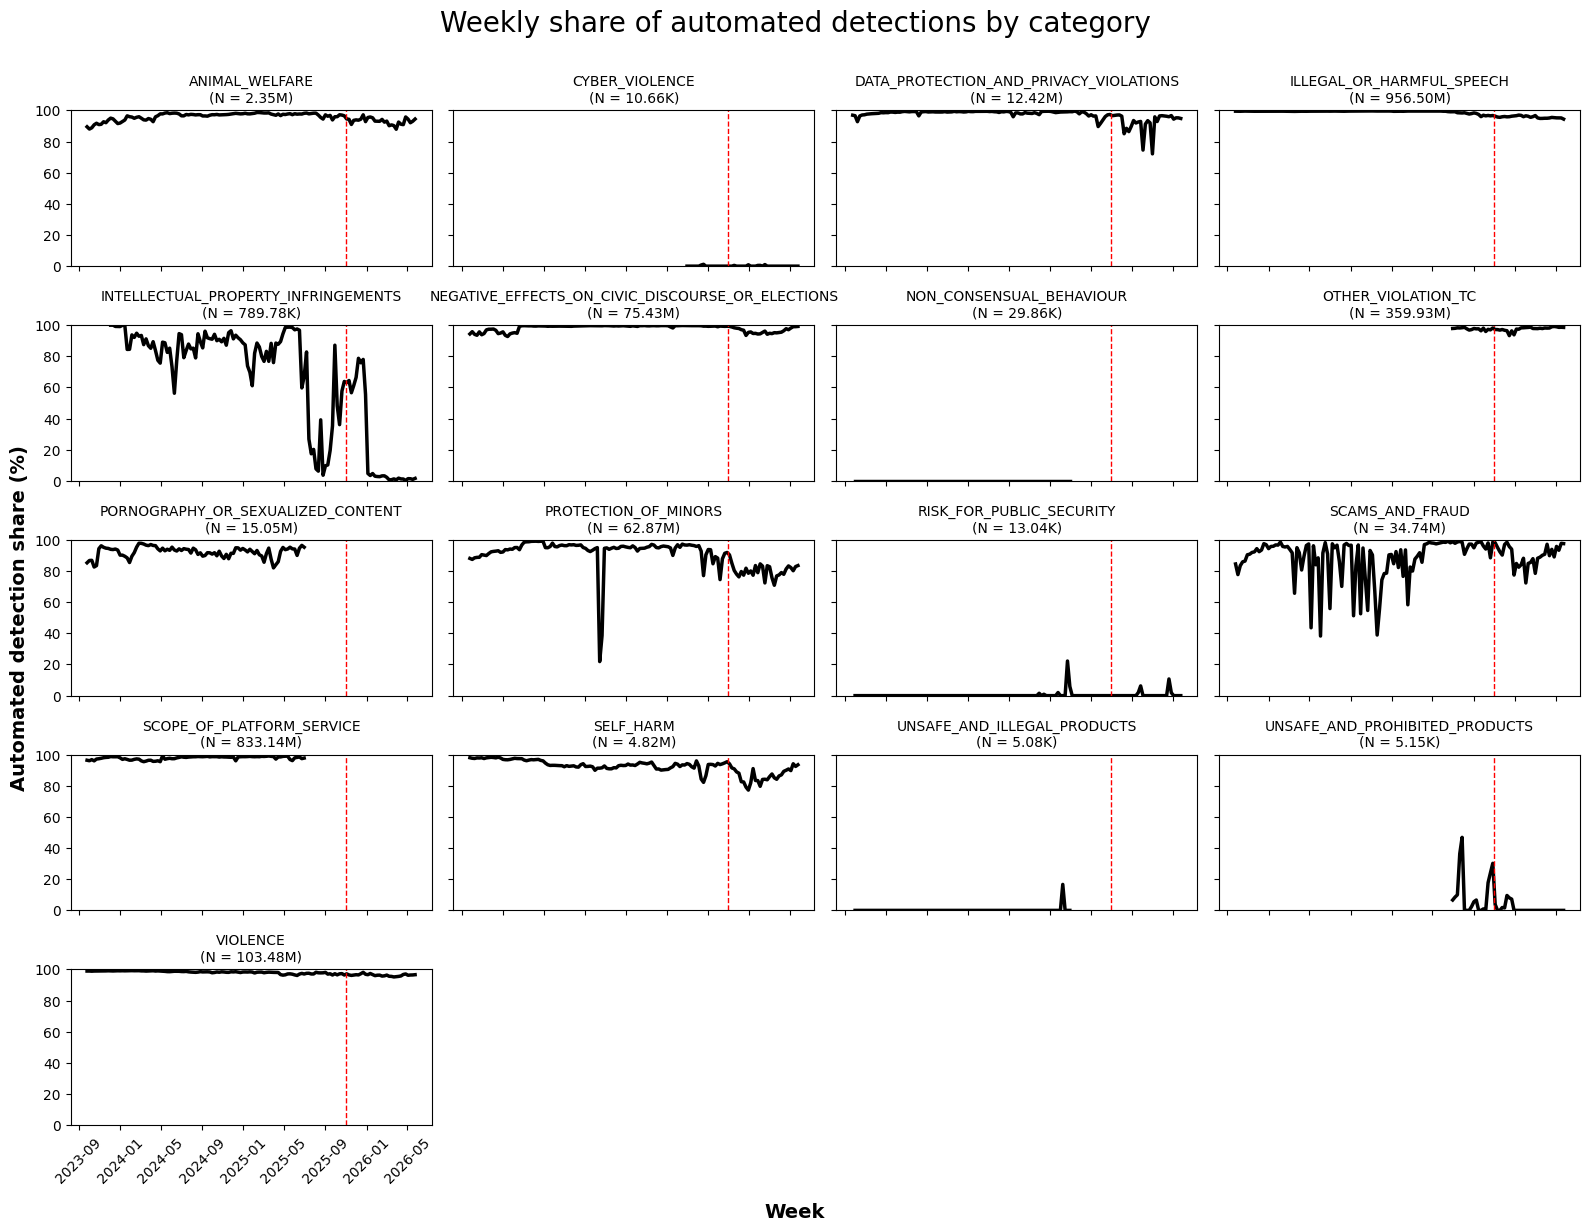

In [50]:
# Dates
det["application_date"] = pd.to_datetime(det["application_date"])

# Convert automated_detection to binary
# Adjust values if your coding differs
det["automated"] = (
    det["automated_detection"]
       .astype(str)
       .str.upper()
       .isin(["YES", "TRUE", "1"])
       .astype(int)
)

# Weekly aggregation by category
weekly = (
    det.assign(
        week=det["application_date"].dt.to_period("W").dt.start_time,
        automated_count=lambda x: x["total"] * x["automated"]
    )
    .groupby(["category_short", "week"], as_index=False)
    .agg(
        total_count=("total", "sum"),
        automated_count=("automated_count", "sum")
    )
)

weekly["share_automated"] = (
    weekly["automated_count"] / weekly["total_count"]
)

# Plot
categories = sorted(weekly["category_short"].unique())

ncols = 4
nrows = int(np.ceil(len(categories) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 2.5 * nrows),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

policy_date = pd.Timestamp("2025-10-31")

for ax, cat in zip(axes, categories):
    tmp = weekly.loc[weekly["category_short"] == cat]
    cat_total = tmp.total_count.sum()
    ax.plot(
        tmp["week"],
        100 * tmp["share_automated"],
        linewidth=2.5, 
        color = 'black'
    )

    ax.axvline(
        policy_date,
        linestyle="--",
        linewidth=1,
        color = 'red'
    )

    ax.set_title(f'{cat}\n(N = {compact(cat_total)})', fontsize=10)
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45)

# Hide unused panels
for ax in axes[len(categories):]:
    ax.set_visible(False)
    
axes[8].set_ylabel("Automated detection share (%)", size = 14, weight = 'bold')
fig.supxlabel("Week", size = 14, weight = 'bold')
fig.suptitle("Weekly share of automated detections by category\n", size = 20)
plt.tight_layout()
plt.savefig('figures/detection_all_cat.png', dpi = 300)

### Video Only

In [17]:
det_vid = det[det['content_type'] == '["CONTENT_TYPE_VIDEO"]']

/var/folders/x5/wbn8vry53vx2_zzm426gt54h0000gn/T/ipykernel_77808/3284120484.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  det_vid["application_date"] = pd.to_datetime(det_vid["application_date"])


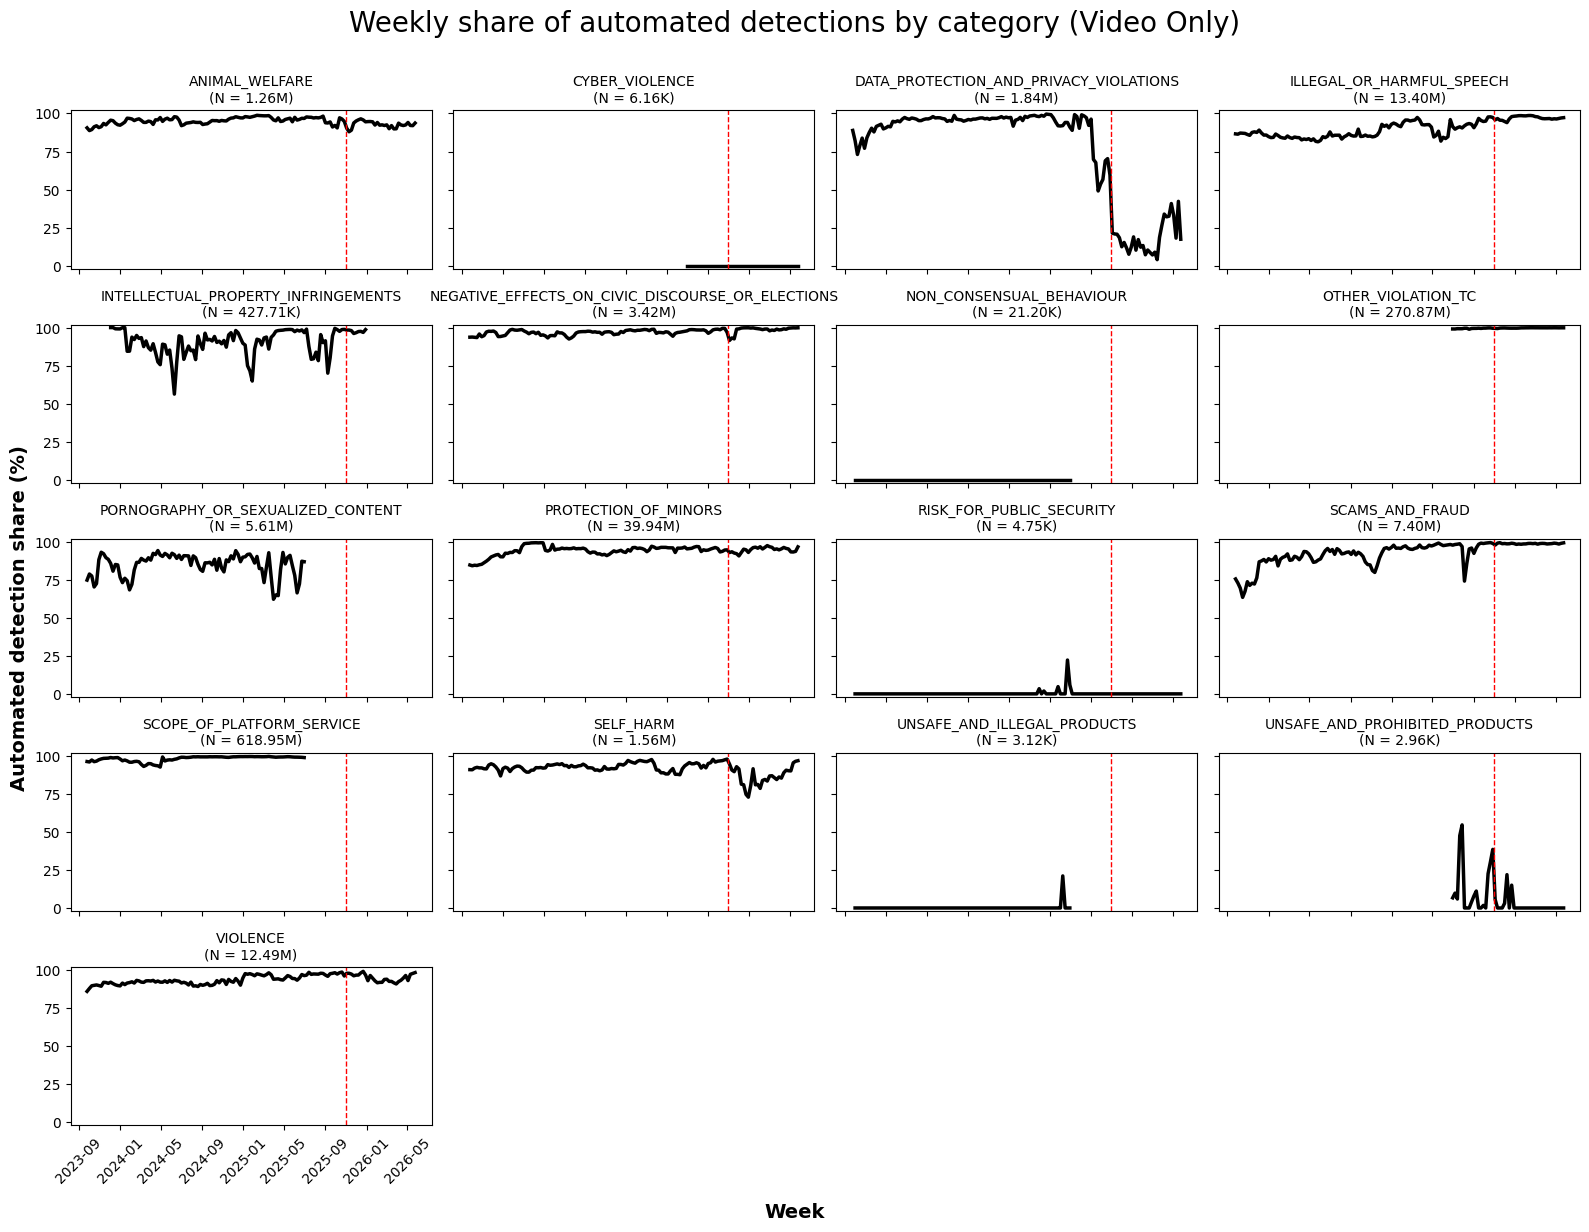

In [32]:
# Dates
det_vid["application_date"] = pd.to_datetime(det_vid["application_date"])

# Weekly aggregation by category
weekly = (
    det_vid.assign(
        week=det_vid["application_date"].dt.to_period("W").dt.start_time,
        automated_count=lambda x: x["total"] * x["automated"]
    )
    .groupby(["category_short", "week"], as_index=False)
    .agg(
        total_count=("total", "sum"),
        automated_count=("automated_count", "sum")
    )
)

weekly["share_automated"] = (
    weekly["automated_count"] / weekly["total_count"]
)

# Plot
categories = sorted(weekly["category_short"].unique())

ncols = 4
nrows = int(np.ceil(len(categories) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 2.5 * nrows),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

policy_date = pd.Timestamp("2025-10-31")

for ax, cat in zip(axes, categories):
    tmp = weekly.loc[weekly["category_short"] == cat]
    cat_total = tmp.total_count.sum()

    ax.plot(
        tmp["week"],
        100 * tmp["share_automated"],
        linewidth=2.5, 
        color = 'black'
    )

    ax.axvline(
        policy_date,
        linestyle="--",
        linewidth=1,
        color = 'red'
    )

    ax.set_title(f'{cat}\n(N = {compact(cat_total)})', fontsize=10)
    ax.set_ylim(-2, 102)
    ax.tick_params(axis="x", rotation=45)

# Hide unused panels
for ax in axes[len(categories):]:
    ax.set_visible(False)
    
axes[8].set_ylabel("Automated detection share (%)", size = 14, weight = 'bold')
fig.supxlabel("Week", size = 14, weight = 'bold')
fig.suptitle("Weekly share of automated detections by category (Video Only)\n", size = 20)

plt.tight_layout()
plt.savefig('figures/detection_video.png', dpi = 300)

### Text Only

In [19]:
det_txt = det[det['content_type'] == '["CONTENT_TYPE_TEXT"]']

/var/folders/x5/wbn8vry53vx2_zzm426gt54h0000gn/T/ipykernel_77808/2174973758.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  det_txt["application_date"] = pd.to_datetime(det_txt["application_date"])


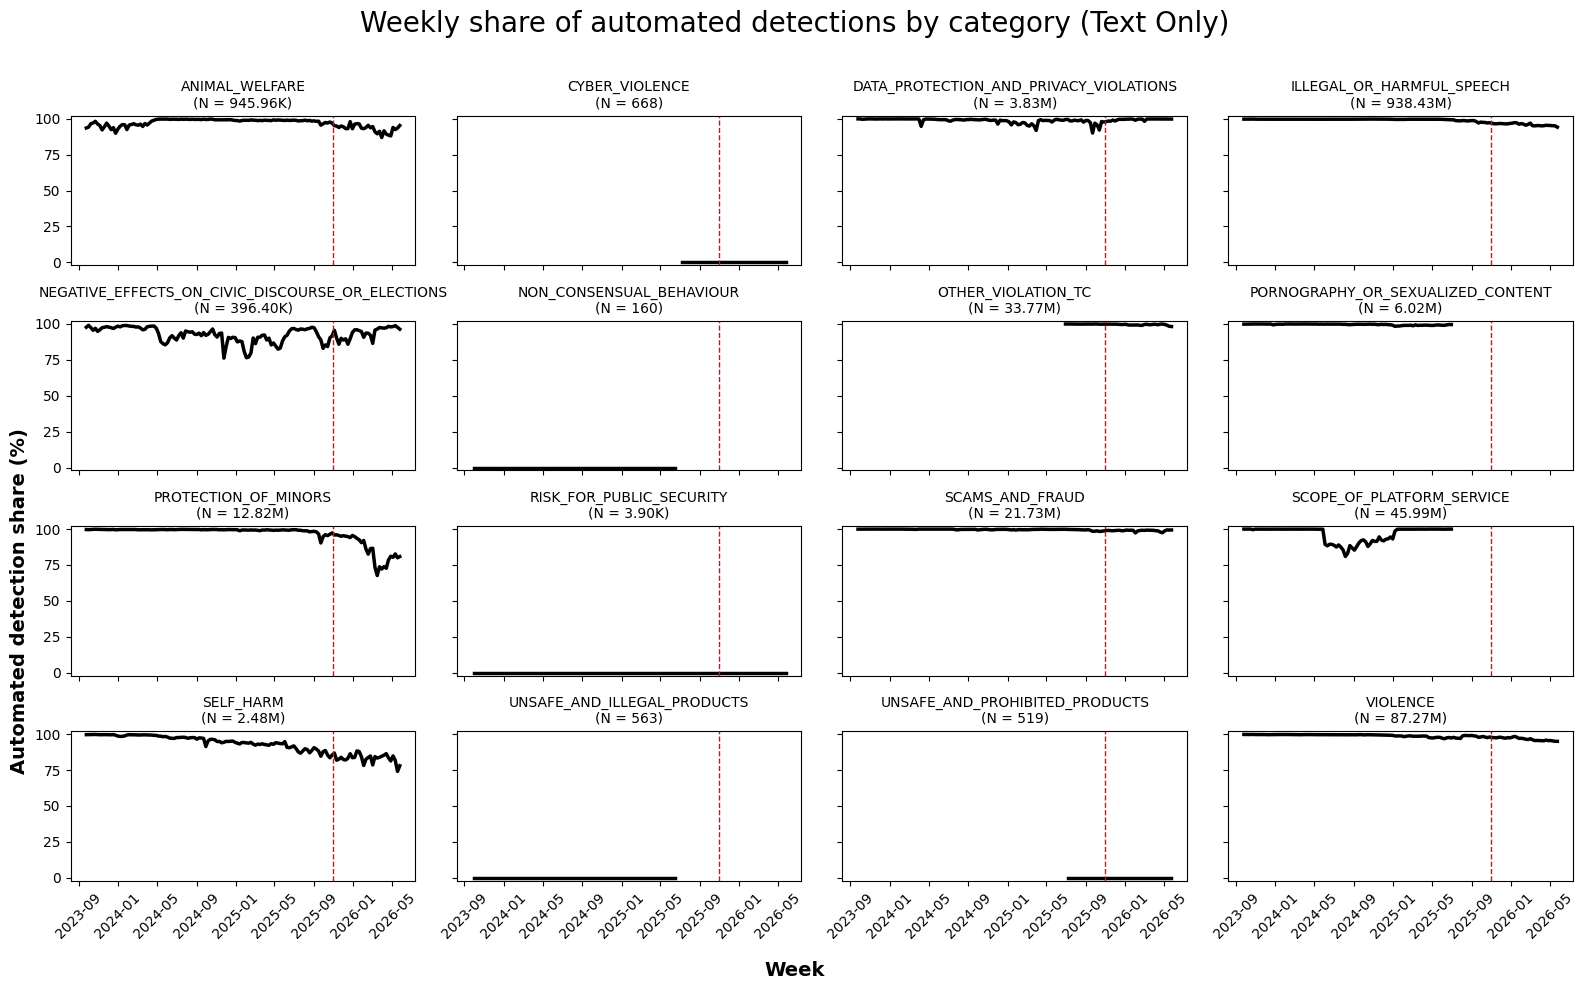

In [33]:
# Dates
det_txt["application_date"] = pd.to_datetime(det_txt["application_date"])

# Weekly aggregation by category
weekly = (
    det_txt.assign(
        week=det_txt["application_date"].dt.to_period("W").dt.start_time,
        automated_count=lambda x: x["total"] * x["automated"]
    )
    .groupby(["category_short", "week"], as_index=False)
    .agg(
        total_count=("total", "sum"),
        automated_count=("automated_count", "sum")
    )
)

weekly["share_automated"] = (
    weekly["automated_count"] / weekly["total_count"]
)

# Plot
categories = sorted(weekly["category_short"].unique())

ncols = 4
nrows = int(np.ceil(len(categories) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 2.5 * nrows),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

policy_date = pd.Timestamp("2025-10-31")

for ax, cat in zip(axes, categories):
    tmp = weekly.loc[weekly["category_short"] == cat]
    cat_total = tmp.total_count.sum()

    ax.plot(
        tmp["week"],
        100 * tmp["share_automated"],
        linewidth=2.5, 
        color = 'black'
    )

    ax.axvline(
        policy_date,
        linestyle="--",
        linewidth=1,
        color = 'red'
    )

    ax.set_title(f'{cat}\n(N = {compact(cat_total)})', fontsize=10)
    ax.set_ylim(-2, 102)
    ax.tick_params(axis="x", rotation=45)

# Hide unused panels
for ax in axes[len(categories):]:
    ax.set_visible(False)
    
axes[8].set_ylabel("Automated detection share (%)", size = 14, weight = 'bold')
fig.supxlabel("Week", size = 14, weight = 'bold')

fig.suptitle("Weekly share of automated detections by category (Text Only)\n", size = 20)


plt.tight_layout()
plt.savefig('figures/detection_text.png', dpi = 300)

# 2. Automated Decisions

In [21]:
dec = pd.read_csv('data/tiktok_automation_dec.csv')

In [22]:
#binary indicator for no automation
dec['any_automation'] = [0 if i == 'AUTOMATED_DECISION_NOT_AUTOMATED' else 1 for i in dec.automated_decision]

In [23]:
dec['application_date'] = pd.to_datetime(dec['application_date'])
dec['post'] = [1 if i > pd.to_datetime('2025-10-31') else 0 for i in dec['application_date']]

### Before After Crosstab

In [24]:
ct2 = pd.crosstab(
    dec["any_automation"],
    dec["post"],
    values=dec["total"],
    aggfunc="sum",
    normalize="columns"
)

print(ct2)

post                   0         1
any_automation                    
0               0.056624  0.073034
1               0.943376  0.926966


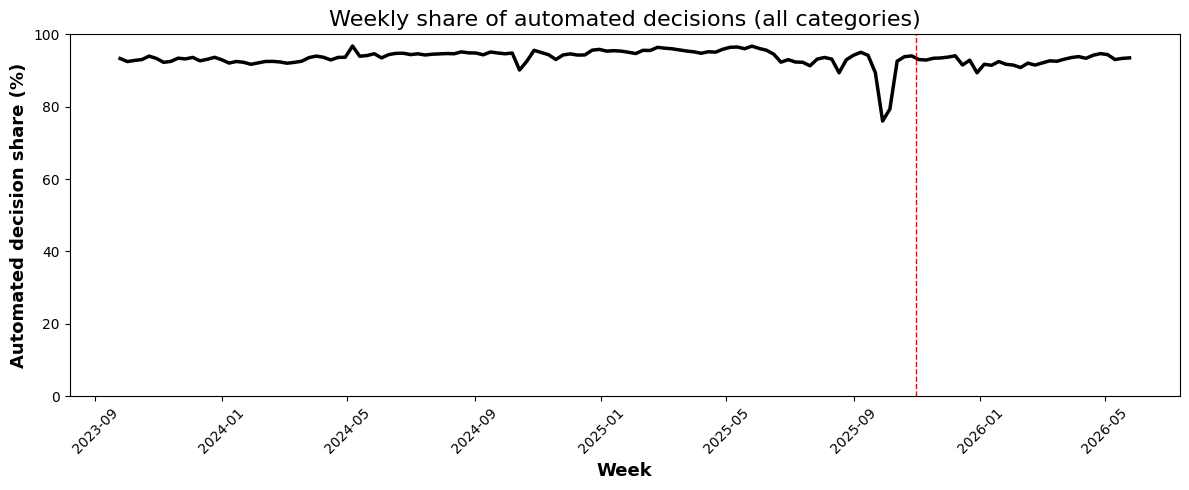

In [53]:
# Dates
dec["application_date"] = pd.to_datetime(dec["application_date"])

# Binary automation indicator
dec["automated"] = (
    dec["any_automation"]
       .astype(str)
       .str.upper()
       .isin(["YES", "TRUE", "1"])
       .astype(int)
)

# Weekly aggregation (NO category split)
weekly_all = (
    dec.assign(
        week=dec["application_date"].dt.to_period("W").dt.start_time,
        automated_count=lambda x: x["total"] * x["automated"]
    )
    .groupby("week", as_index=False)
    .agg(
        total_count=("total", "sum"),
        automated_count=("automated_count", "sum")
    )
)

# Share
weekly_all["share_automated"] = (
    weekly_all["automated_count"] / weekly_all["total_count"]
)

# Policy cutoff
policy_date = pd.Timestamp("2025-10-31")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    weekly_all["week"],
    100 * weekly_all["share_automated"],
    linewidth=2.5,
    color="black"
)

ax.axvline(
    policy_date,
    linestyle="--",
    linewidth=1,
    color="red"
)

ax.set_ylim(0, 100)
ax.set_ylabel("Automated decision share (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Week", fontsize=13, fontweight="bold")
ax.set_title("Weekly share of automated decisions (all categories)", fontsize=16)

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("figures/decision_all.png", dpi=300)
plt.show()

### No other TC violation

/var/folders/x5/wbn8vry53vx2_zzm426gt54h0000gn/T/ipykernel_77808/2635161568.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dec_notc["application_date"] = pd.to_datetime(dec_notc["application_date"])
/var/folders/x5/wbn8vry53vx2_zzm426gt54h0000gn/T/ipykernel_77808/2635161568.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dec_notc["automated"] = (


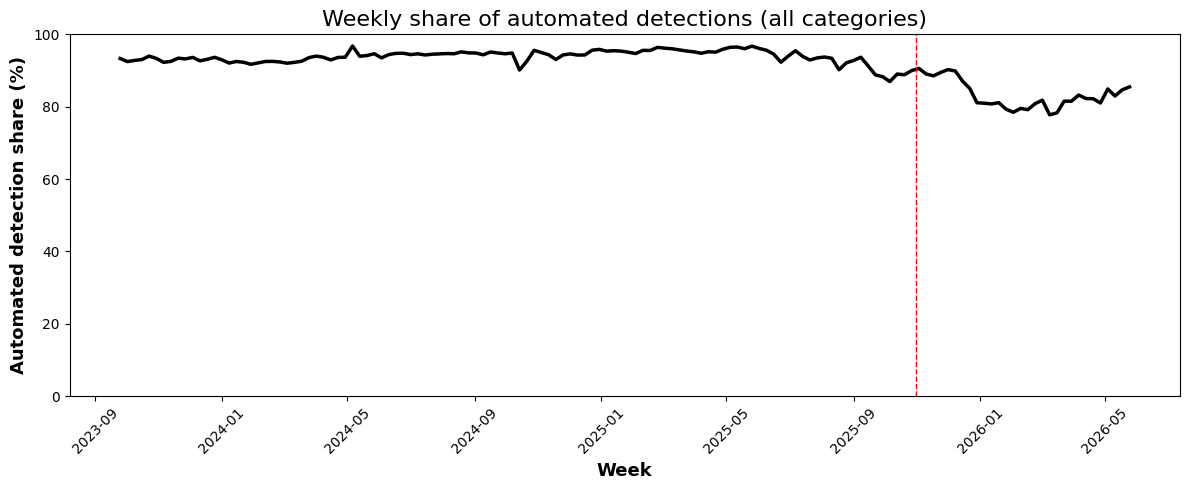

In [63]:

dec_notc = dec[(dec['category'] != 'STATEMENT_CATEGORY_OTHER_VIOLATION_TC')]
dec_notc["application_date"] = pd.to_datetime(dec_notc["application_date"])

# Binary automation indicator
dec_notc["automated"] = (
    dec_notc["any_automation"]
       .astype(str)
       .str.upper()
       .isin(["YES", "TRUE", "1"])
       .astype(int)
)

# Weekly aggregation (NO category split)
weekly_all = (
    dec_notc.assign(
        week=dec_notc["application_date"].dt.to_period("W").dt.start_time,
        automated_count=lambda x: x["total"] * x["automated"]
    )
    .groupby("week", as_index=False)
    .agg(
        total_count=("total", "sum"),
        automated_count=("automated_count", "sum")
    )
)

# Share
weekly_all["share_automated"] = (
    weekly_all["automated_count"] / weekly_all["total_count"]
)

# Policy cutoff
policy_date = pd.Timestamp("2025-10-31")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    weekly_all["week"],
    100 * weekly_all["share_automated"],
    linewidth=2.5,
    color="black"
)

ax.axvline(
    policy_date,
    linestyle="--",
    linewidth=1,
    color="red"
)

ax.set_ylim(0, 100)
ax.set_ylabel("Automated detection share (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Week", fontsize=13, fontweight="bold")
ax.set_title("Weekly share of automated detections (all categories)", fontsize=16)

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("figures/decision_all_no_other.png", dpi=300)
plt.show()

### All decisions

In [25]:
#shorten category names for display
dec['category_short'] = [i[19:] for i in dec['category']]

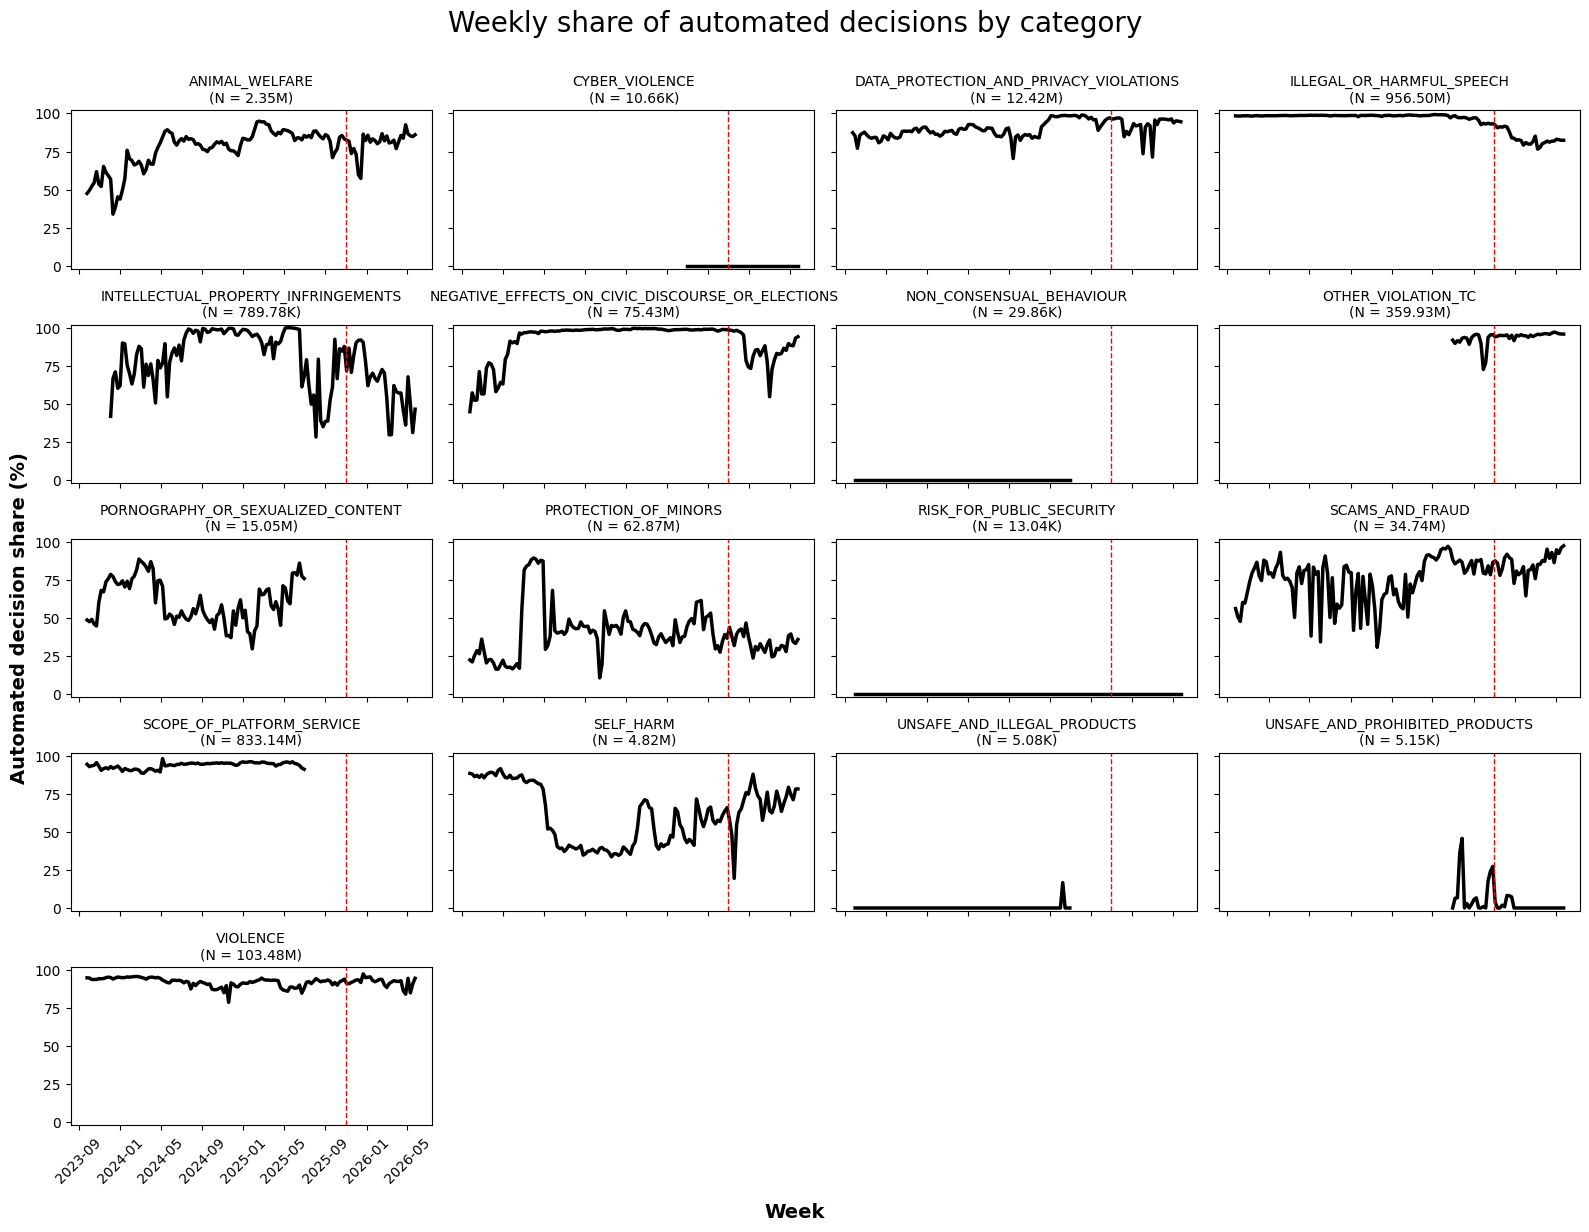

In [52]:
# Dates
dec["application_date"] = pd.to_datetime(dec["application_date"])

# Convert automated_detection to binary
# Adjust values if your coding differs
dec["automated"] = (
    dec["any_automation"]
       .astype(str)
       .str.upper()
       .isin(["YES", "TRUE", "1"])
       .astype(int)
)

# Weekly aggregation by category
weekly = (
    dec.assign(
        week=dec["application_date"].dt.to_period("W").dt.start_time,
        automated_count=lambda x: x["total"] * x["automated"]
    )
    .groupby(["category_short", "week"], as_index=False)
    .agg(
        total_count=("total", "sum"),
        automated_count=("automated_count", "sum")
    )
)

weekly["share_automated"] = (
    weekly["automated_count"] / weekly["total_count"]
)

# Plot
categories = sorted(weekly["category_short"].unique())

ncols = 4
nrows = int(np.ceil(len(categories) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 2.5 * nrows),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

policy_date = pd.Timestamp("2025-10-31")

for ax, cat in zip(axes, categories):
    tmp = weekly.loc[weekly["category_short"] == cat]
    cat_total = tmp.total_count.sum()

    ax.plot(
        tmp["week"],
        100 * tmp["share_automated"],
        linewidth=2.5, 
        color = 'black'
    )

    ax.axvline(
        policy_date,
        linestyle="--",
        linewidth=1,
        color = 'red'
    )

    ax.set_title(f'{cat}\n(N = {compact(cat_total)})', fontsize=10)
    ax.set_ylim(-2, 102)
    ax.tick_params(axis="x", rotation=45)

# Hide unused panels
for ax in axes[len(categories):]:
    ax.set_visible(False)
    
axes[8].set_ylabel("Automated decision share (%)", size = 14, weight = 'bold')
fig.supxlabel("Week", size = 14, weight = 'bold')
fig.suptitle("Weekly share of automated decisions by category\n", size = 20)
plt.tight_layout()
plt.savefig('figures/decision_all_cat.png', dpi = 300)

### Videos Only

In [27]:
dec_vid = dec[dec['content_type'] == '["CONTENT_TYPE_VIDEO"]']

/var/folders/x5/wbn8vry53vx2_zzm426gt54h0000gn/T/ipykernel_77808/3740361590.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dec_vid["application_date"] = pd.to_datetime(dec_vid["application_date"])
/var/folders/x5/wbn8vry53vx2_zzm426gt54h0000gn/T/ipykernel_77808/3740361590.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dec_vid["automated"] = (


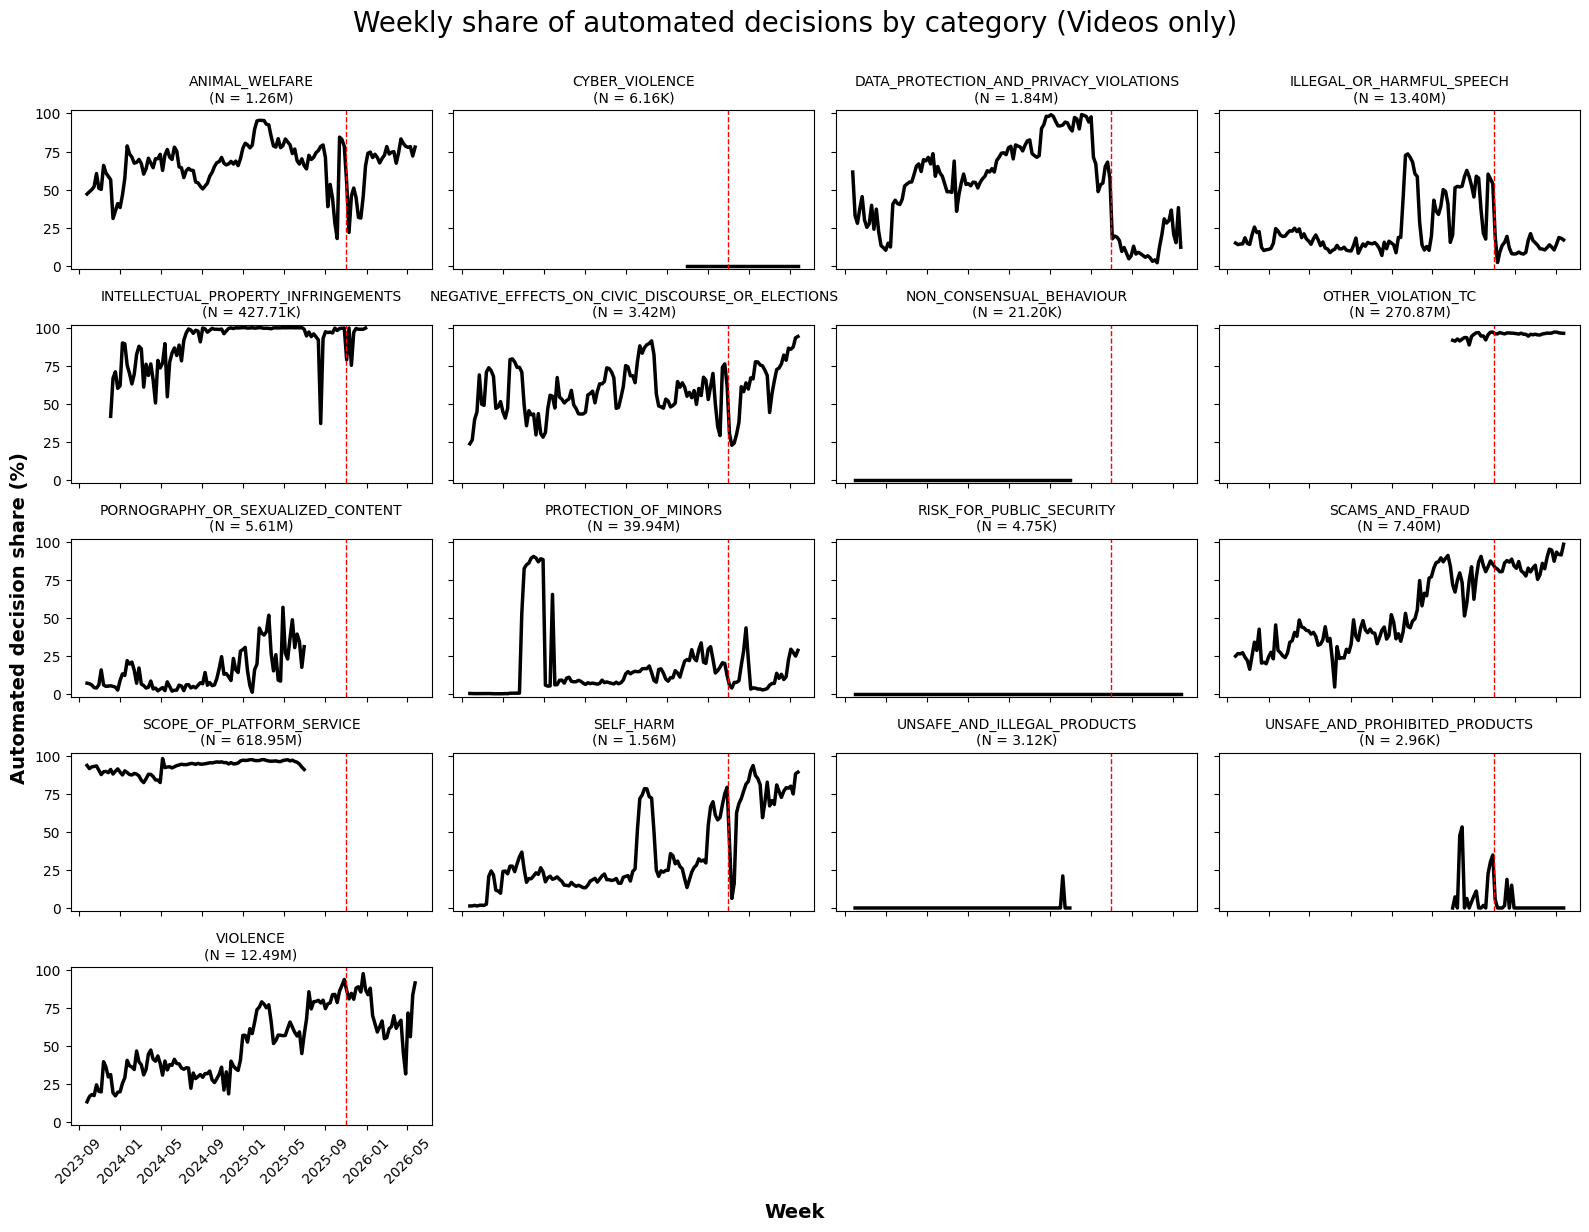

In [44]:
# Dates
dec_vid["application_date"] = pd.to_datetime(dec_vid["application_date"])

# Convert automated_detection to binary
# Adjust values if your coding differs
dec_vid["automated"] = (
    dec_vid["any_automation"]
       .astype(str)
       .str.upper()
       .isin(["YES", "TRUE", "1"])
       .astype(int)
)

# Weekly aggregation by category
weekly = (
    dec_vid.assign(
        week=dec_vid["application_date"].dt.to_period("W").dt.start_time,
        automated_count=lambda x: x["total"] * x["automated"]
    )
    .groupby(["category_short", "week"], as_index=False)
    .agg(
        total_count=("total", "sum"),
        automated_count=("automated_count", "sum")
    )
)

weekly["share_automated"] = (
    weekly["automated_count"] / weekly["total_count"]
)

# Plot
categories = sorted(weekly["category_short"].unique())

ncols = 4
nrows = int(np.ceil(len(categories) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 2.5 * nrows),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

policy_date = pd.Timestamp("2025-10-31")

for ax, cat in zip(axes, categories):
    tmp = weekly.loc[weekly["category_short"] == cat]
    cat_total = tmp.total_count.sum()

    ax.plot(
        tmp["week"],
        100 * tmp["share_automated"],
        linewidth=2.5, 
        color = 'black'
    )

    ax.axvline(
        policy_date,
        linestyle="--",
        linewidth=1,
        color = 'red'
    )

    ax.set_title(f'{cat}\n(N = {compact(cat_total)})', fontsize=10)
    ax.set_ylim(-2, 102)
    ax.tick_params(axis="x", rotation=45)

# Hide unused panels
for ax in axes[len(categories):]:
    ax.set_visible(False)
    
axes[8].set_ylabel("Automated decision share (%)", size = 14, weight = 'bold')
fig.supxlabel("Week", size = 14, weight = 'bold')
fig.suptitle("Weekly share of automated decisions by category (Videos only)\n", size = 20)
plt.tight_layout()
plt.savefig('figures/decision_video.png', dpi = 300)

### Tetxt Only

In [29]:
dec_txt = dec[dec['content_type'] == '["CONTENT_TYPE_TEXT"]']

/var/folders/x5/wbn8vry53vx2_zzm426gt54h0000gn/T/ipykernel_77808/2990673657.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dec_txt["application_date"] = pd.to_datetime(dec_txt["application_date"])
/var/folders/x5/wbn8vry53vx2_zzm426gt54h0000gn/T/ipykernel_77808/2990673657.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dec_txt["automated"] = (


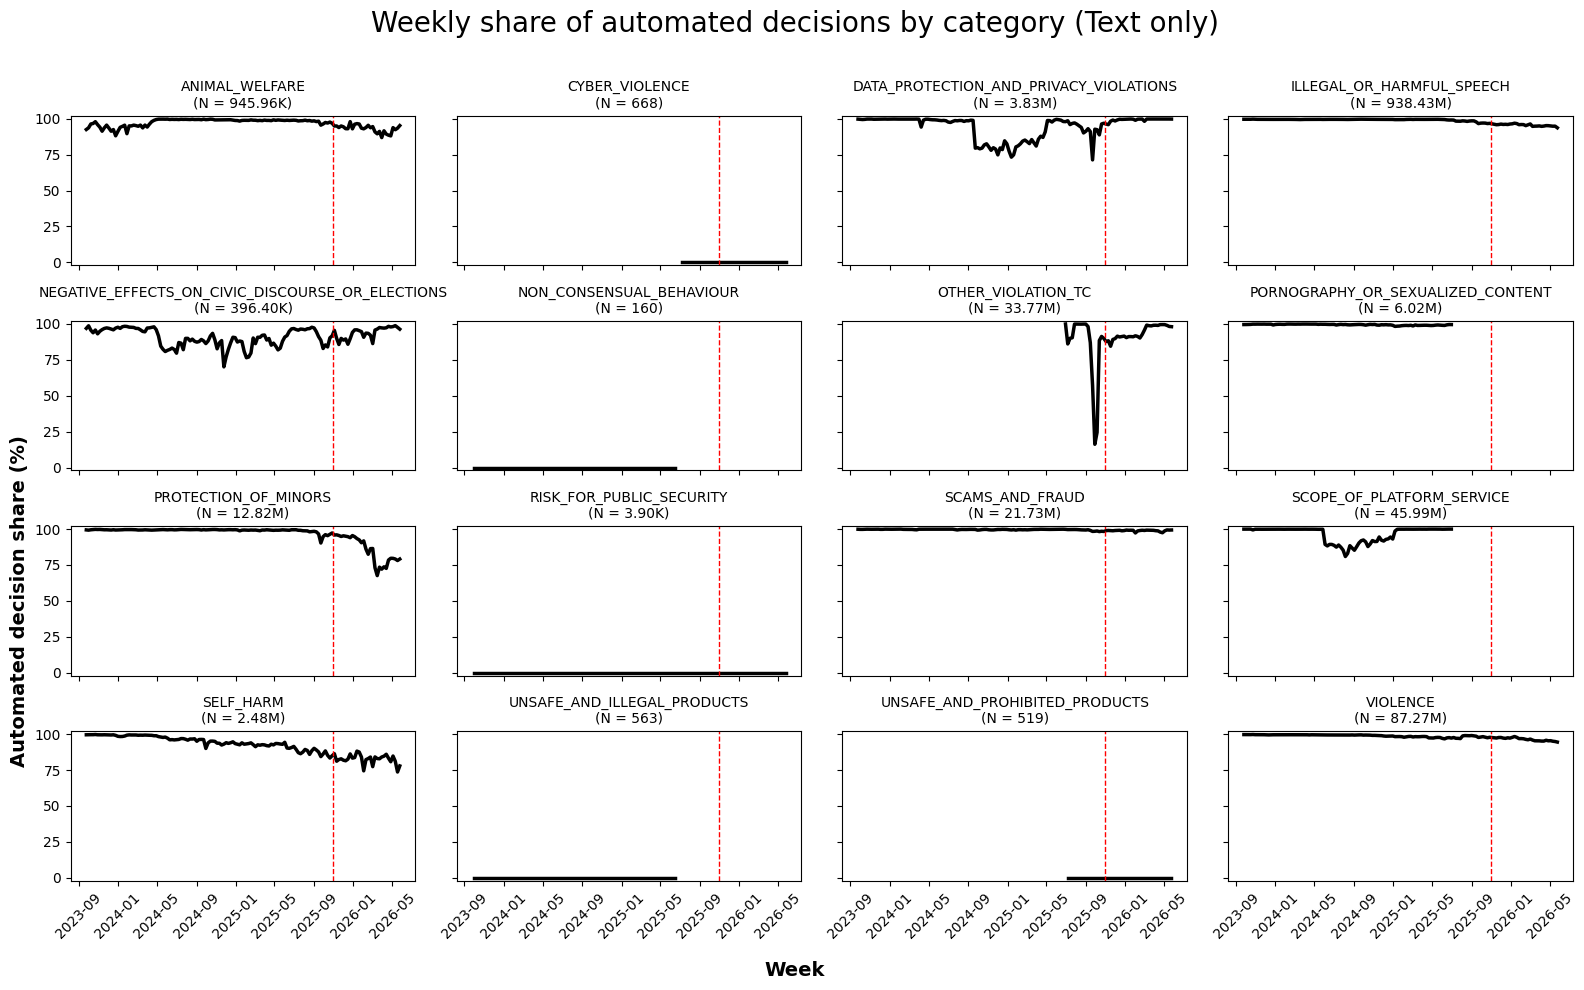

In [45]:
# Dates
dec_txt["application_date"] = pd.to_datetime(dec_txt["application_date"])

# Convert automated_detection to binary
# Adjust values if your coding differs
dec_txt["automated"] = (
    dec_txt["any_automation"]
       .astype(str)
       .str.upper()
       .isin(["YES", "TRUE", "1"])
       .astype(int)
)

# Weekly aggregation by category
weekly = (
    dec_txt.assign(
        week=dec_txt["application_date"].dt.to_period("W").dt.start_time,
        automated_count=lambda x: x["total"] * x["automated"]
    )
    .groupby(["category_short", "week"], as_index=False)
    .agg(
        total_count=("total", "sum"),
        automated_count=("automated_count", "sum")
    )
)

weekly["share_automated"] = (
    weekly["automated_count"] / weekly["total_count"]
)

# Plot
categories = sorted(weekly["category_short"].unique())

ncols = 4
nrows = int(np.ceil(len(categories) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 2.5 * nrows),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

policy_date = pd.Timestamp("2025-10-31")

for ax, cat in zip(axes, categories):
    tmp = weekly.loc[weekly["category_short"] == cat]
    cat_total = tmp.total_count.sum()


    ax.plot(
        tmp["week"],
        100 * tmp["share_automated"],
        linewidth=2.5, 
        color = 'black'
    )

    ax.axvline(
        policy_date,
        linestyle="--",
        linewidth=1,
        color = 'red'
    )

    ax.set_title(f'{cat}\n(N = {compact(cat_total)})', fontsize=10)
    ax.set_ylim(-2, 102)
    ax.tick_params(axis="x", rotation=45)

# Hide unused panels
for ax in axes[len(categories):]:
    ax.set_visible(False)
    
axes[8].set_ylabel("Automated decision share (%)", size = 14, weight = 'bold')
fig.supxlabel("Week", size = 14, weight = 'bold')
fig.suptitle("Weekly share of automated decisions by category (Text only)\n", size = 20)
plt.tight_layout()
plt.savefig('figures/decision_text.png', dpi = 300)